# RMSE Fitness Tuning

This notebook covers the full pipeline for the RMSE fitness function: parameter tuning by trial and error (informed by the random search in `01_experiment_tracking`), statistical comparison of the Memetic GA against the pure GA and of diversity mechanisms against a clean baseline, and the final long run that produces the best solution.

A more exhaustive random search was not feasible due to hardware constraints.

## Setup

In [ ]:
from pathlib import Path
from copy import deepcopy
from itertools import combinations
import sys
import pickle
import random
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import wilcoxon
from IPython.display import display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.config import CANVAS_H, CANVAS_W, DATA_PATH, DEFAULT_SEED, RESULTS_DIR
from src.models import TriangleSolution
from src.ga.engine import genetic_algorithm, hill_climbing_refine, _build_genotype_matrix, _ensure_population_fitness
from src.operators import gaussian_mutation
from src.utils import build_ga_operators, create_run_gif, plot_run_summary

/opt/anaconda3/envs/cifo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
target_img = Image.open(DATA_PATH).convert('RGB').resize((CANVAS_W, CANVAS_H))
target_array = np.array(target_img, dtype=np.uint8)
TriangleSolution.target = target_array

## Configuration

The random search found a best configuration with mean RMSE of 38.20 (std=1.64): pop=100, tournament selection (size=5), uniform crossover
(xo=0.78), mixed mutation (mut=0.064, swap=0.41, sigma=2.3->0.14), no elitism, and plateau window=20. When run for the full 6000 generations, this configuration achieved a final RMSE of 27.75.

Manual tuning from this starting point led to the following changes:
- **Elitism enabled** (n_elites=1): prevents the best solution from being lost across generations, improving convergence stability.
- **Lower mutation rate** (0.064 -> 0.021) and **lower swap weight** (0.41 -> 0.11): reduces destructive mutations in later generations where fine-tuning is more important than exploration.
- **Higher crossover probability** (0.78 -> 0.87): encourages more recombination between good solutions.
- **Wider sigma decay** (2.3->0.14 to 1.30->0.16): starts with more aggressive mutations and decays more gradually.
- **Larger plateau window** (20 -> 40): avoids triggering diversity injection too eagerly in early generations where fitness is still improving rapidly.

The manually tuned configuration achieved a final RMSE of 24.14, an improvement of 3.61 over the random search best.

In [5]:
# Hill Climbing constants
HC_ITERATIONS = 80
HC_NEIGHBORS = 15
HC_MUT_PROB = 0.03
HC_SIGMA_SCALE = 0.10

rmse_params = {
    "pop_size": 100,
    "selection_name": "tournament",
    "crossover_name": "uniform",
    "mutation_name": "mixed",
    "tournament_size": 5,
    "swap_weight": 0.11,
    "ga_settings": {
        "xo_prob": 0.87,
        "mut_prob": 0.021,
        "elitism": True,
        "n_elites": 1,
        "verbose": False,
        "diversify_on_plateau": True,
        "plateau_window": 40,
        "plateau_epsilon": 0.05,
        "mut_sigma_start": 1.30,
        "mut_sigma_end": 0.16,
        "hc_refine_every": 0,
    },
    "selected_experiment": "manual_tuned",
    "solution_class": "TriangleSolution",
}

## GA vs Memetic GA - Statistical Comparison

Before committing to the final long run, we evaluate the contribution of Hill Climbing by comparing the pure GA (no HC) against the Memetic GA (periodic HC
refinement + final polishing), using the same operators and generation budget. Both variants run across `N_HC_SEEDS` independent seeds; differences in final
RMSE are assessed with the Wilcoxon signed-rank test (α = 0.05).

In [ ]:
N_HC_SEEDS   = 30    # ≥30 for statistical validity (Week 12)
HC_BASE_SEED = 67
HC_MAX_GENS  = 200  # same budget for both variants
ALPHA        = 0.05


def _run_ga_no_hc(seed):
    """Pure GA with HC fully disabled (hc_refine_every=0)."""
    random.seed(seed)
    np.random.seed(seed)
    sel, xo, mut = build_ga_operators(rmse_params)
    settings = {
        **rmse_params["ga_settings"],
        "verbose": False, "return_metrics": False,
        "save_best_per_generation": False,
        "hc_refine_every": 0,
    }
    _, history = genetic_algorithm(
        initial_population=[TriangleSolution() for _ in range(rmse_params["pop_size"])],
        max_generations=HC_MAX_GENS,
        selection_algorithm=sel, xo_method=xo, mut_method=mut,
        settings=settings,
    )
    return history


def _run_memetic_ga(seed):
    """Memetic GA: same GA + periodic HC + final polishing."""
    random.seed(seed)
    np.random.seed(seed)
    sel, xo, mut = build_ga_operators(rmse_params)
    settings = {
        **rmse_params["ga_settings"],
        "verbose": False, "return_metrics": False,
        "save_best_per_generation": False,
        "hc_refine_every": 50,
        "hc_iterations": HC_ITERATIONS, "hc_neighbors": HC_NEIGHBORS,
        "hc_mut_prob": HC_MUT_PROB, "hc_sigma_scale": HC_SIGMA_SCALE,
        "hc_mut_method": gaussian_mutation,
    }
    best, history = genetic_algorithm(
        initial_population=[TriangleSolution() for _ in range(rmse_params["pop_size"])],
        max_generations=HC_MAX_GENS,
        selection_algorithm=sel, xo_method=xo, mut_method=mut,
        settings=settings,
    )
    refined = hill_climbing_refine(
        best, gaussian_mutation, mut_prob=0.02, sigma_scale=0.05,
        n_iterations=100, n_neighbors=20,
    )
    history.append(min(best.fitness(), refined.fitness()))
    return history

In [18]:
seeds_hc = [HC_BASE_SEED + i for i in range(N_HC_SEEDS)]
histories_pure, histories_memetic = [], []

for i, seed in enumerate(seeds_hc):
    print(f"Seed {seed} ({i+1}/{N_HC_SEEDS}) ...", end=" ", flush=True)
    h_pure = _run_ga_no_hc(seed)
    histories_pure.append(h_pure)
    h_mem = _run_memetic_ga(seed)
    histories_memetic.append(h_mem)
    print(f"GA={h_pure[-1]:.4f} | Memetic={h_mem[-1]:.4f}")

final_pure    = np.array([h[-1] for h in histories_pure])
final_memetic = np.array([h[-1] for h in histories_memetic])

display(pd.DataFrame([
    {"Algorithm": "GA (no HC)",          "Mean": f"{final_pure.mean():.4f}",    "Median": f"{np.median(final_pure):.4f}",    "Std": f"{final_pure.std():.4f}"},
    {"Algorithm": "Memetic GA (GA + HC)", "Mean": f"{final_memetic.mean():.4f}", "Median": f"{np.median(final_memetic):.4f}", "Std": f"{final_memetic.std():.4f}"},
]).set_index("Algorithm"))

Seed 67 (1/30) ... GA=38.7117 | Memetic=38.4494
Seed 68 (2/30) ... GA=41.8162 | Memetic=41.0644
Seed 69 (3/30) ... GA=41.8007 | Memetic=39.5040
Seed 70 (4/30) ... GA=40.5355 | Memetic=40.5405
Seed 71 (5/30) ... GA=41.6925 | Memetic=37.7459
Seed 72 (6/30) ... GA=37.0705 | Memetic=36.9706
Seed 73 (7/30) ... GA=38.4521 | Memetic=36.4008
Seed 74 (8/30) ... GA=44.2018 | Memetic=41.1172
Seed 75 (9/30) ... GA=43.7353 | Memetic=44.0427
Seed 76 (10/30) ... GA=40.1445 | Memetic=38.3321
Seed 77 (11/30) ... GA=38.8101 | Memetic=38.7571
Seed 78 (12/30) ... GA=42.3652 | Memetic=41.3394
Seed 79 (13/30) ... GA=41.0078 | Memetic=39.6555
Seed 80 (14/30) ... GA=44.9765 | Memetic=41.4279
Seed 81 (15/30) ... GA=40.8061 | Memetic=39.4256
Seed 82 (16/30) ... GA=41.5126 | Memetic=41.4718
Seed 83 (17/30) ... GA=37.9331 | Memetic=34.7955
Seed 84 (18/30) ... GA=40.5556 | Memetic=38.8572
Seed 85 (19/30) ... GA=42.2588 | Memetic=41.3132
Seed 86 (20/30) ... GA=39.4513 | Memetic=35.9340
Seed 87 (21/30) ... GA=41.181

,Mean,Median,Std
Algorithm,,,
GA (no HC),41.1265,41.0949,1.9263
Memetic GA (GA + HC),39.4603,39.5797,1.9954


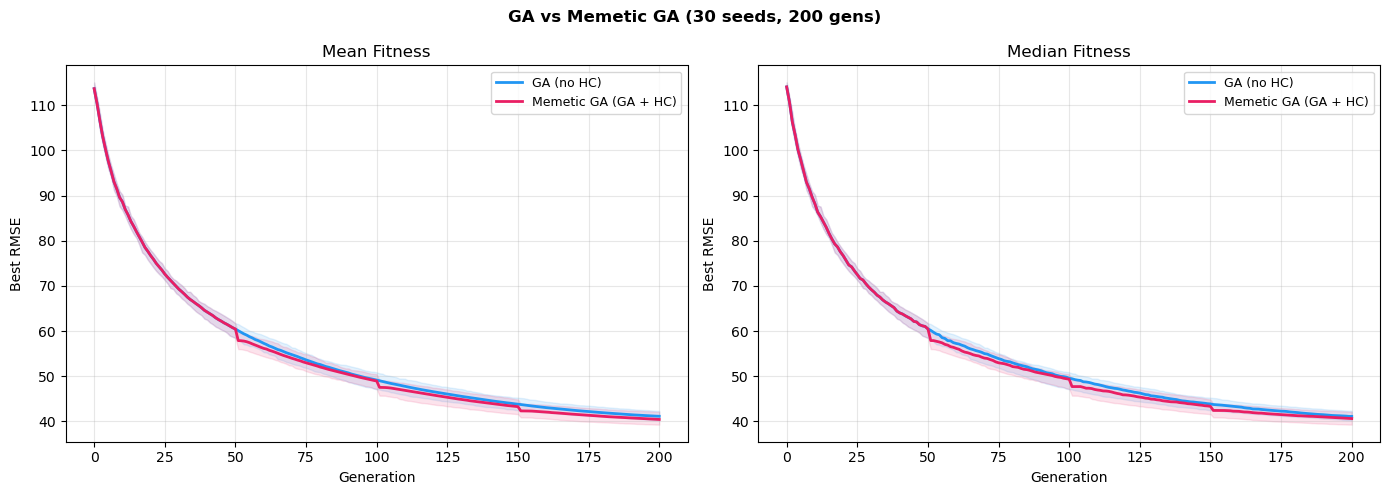

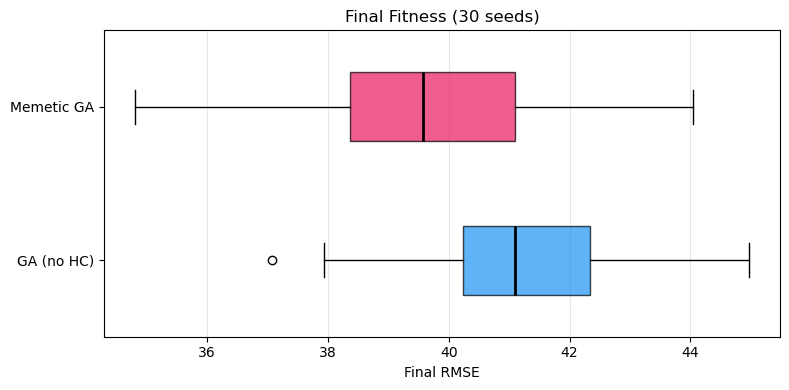

Wilcoxon: statistic=13.0000, p=0.000000
Significant (α=0.05)


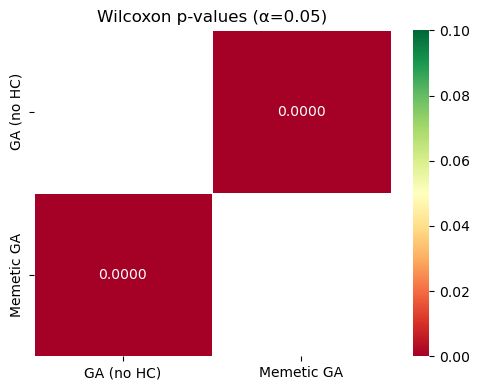

In [19]:
COLORS = {"GA (no HC)": "#2196F3", "Memetic GA (GA + HC)": "#E91E63"}
min_len  = min(min(len(h) for h in histories_pure), min(len(h) for h in histories_memetic))
mat_pure = np.vstack([h[:min_len] for h in histories_pure])
mat_mem  = np.vstack([h[:min_len] for h in histories_memetic])

# Convergence curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"GA vs Memetic GA ({N_HC_SEEDS} seeds, {HC_MAX_GENS} gens)", fontsize=12, fontweight="bold")
for ax, (stat_label, fn) in zip(axes, [("Mean", np.mean), ("Median", np.median)]):
    for label, mat in [("GA (no HC)", mat_pure), ("Memetic GA (GA + HC)", mat_mem)]:
        curve = fn(mat, axis=0)
        ax.plot(np.arange(min_len), curve, label=label, color=COLORS[label], linewidth=2)
        ax.fill_between(np.arange(min_len), np.quantile(mat, 0.25, axis=0), np.quantile(mat, 0.75, axis=0), color=COLORS[label], alpha=0.12)
    ax.set_title(f"{stat_label} Fitness"); ax.set_xlabel("Generation"); ax.set_ylabel("Best RMSE")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Boxplots
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([final_pure, final_memetic], vert=False, patch_artist=True, widths=0.45,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], [COLORS["GA (no HC)"], COLORS["Memetic GA (GA + HC)"]]):
    patch.set_facecolor(color); patch.set_alpha(0.72)
ax.set_yticks([1, 2]); ax.set_yticklabels(["GA (no HC)", "Memetic GA"], fontsize=10)
ax.set_xlabel("Final RMSE"); ax.set_title(f"Final Fitness ({N_HC_SEEDS} seeds)"); ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# Wilcoxon
stat, p_value = wilcoxon(final_pure, final_memetic, alternative="two-sided")
print(f"Wilcoxon: statistic={stat:.4f}, p={p_value:.6f}")
print("Significant" if p_value < ALPHA else "Not significant", f"(α={ALPHA})")

# Heatmap
labels_s = ["GA (no HC)", "Memetic GA"]
p_mat = pd.DataFrame([[1.0, p_value], [p_value, 1.0]], index=labels_s, columns=labels_s)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(p_mat, annot=True, fmt=".4f", cmap="RdYlGn", vmin=0, vmax=0.10,
            linewidths=0.5, mask=np.eye(2, dtype=bool), ax=ax)
ax.set_title(f"Wilcoxon p-values (α={ALPHA})"); plt.tight_layout(); plt.show()

### Results

Both algorithms converge at a similar rate during the first 50 generations. From that point onwards, the Memetic GA shows visible improvement steps at generations 50, 100, and 150 - precisely where the HC refinement triggers - confirming that the periodic local search is actively improving the best solution at each refinement point. The IQR bands are narrow and overlapping throughout, suggesting high consistency across seeds.

The Wilcoxon signed-rank test confirms the difference is statistically significant (p=0.0000 < 0.05): the Memetic GA achieves consistently lower final RMSE than the pure GA. HC refinement every 50 generations, combined with a final polishing pass, provides a reliable improvement that justifies the additional computational cost. The long run therefore uses the Memetic configuration.

## Diversity Mechanisms - Statistical Comparison

The Memetic GA showed a statistically significant improvement over the pure GA (p < 0.05, Wilcoxon signed-rank test). We now evaluate three additional diversity strategies - Plateau Diversity, Fitness Sharing, and Restricted Mating - against a clean baseline with all mechanisms disabled. All four variants share the same operators, population size, and generation budget (200 generations, 30 seeds), differing only in the diversity mechanism under
evaluation.

Plateau diversity uses a reactive approach: it monitors fitness stagnation over a sliding window and reinjects random individuals when a plateau is detected. For this comparison, the window was reduced to 10 generations (from 40 in the long run) to ensure the mechanism triggers within the 200-generation budget.

In [ ]:
N_DIV_SEEDS   = 30
DIV_BASE_SEED = 67
DIV_MAX_GENS  = 200
ALPHA_DIV     = 0.05


# Base settings with all diversity mechanisms off
_DIV_SETTINGS_BASE = {
    **rmse_params["ga_settings"],
    "verbose": False,
    "return_metrics": False,
    "save_best_per_generation": False,
    "hc_refine_every": 0,
    "diversify_on_plateau": False,  # off for fair comparison
}

def _pairwise_norm_distances(population):
    """Normalised L2 distance matrix in [0,1] from population genotypes."""
    G   = _build_genotype_matrix(population)
    sq  = np.sum(G**2, axis=1, keepdims=True)
    raw = np.sqrt(np.clip(sq + sq.T - 2 * G @ G.T, 0, None))
    mx  = raw.max()
    return raw / mx if mx > 0 else raw

In [ ]:
def _run_baseline_div(seed):
    """Baseline GA - no diversity mechanism."""
    random.seed(seed); np.random.seed(seed)
    sel, xo, mut = build_ga_operators(rmse_params)
    _, history = genetic_algorithm(
        initial_population=[TriangleSolution() for _ in range(rmse_params["pop_size"])],
        max_generations=DIV_MAX_GENS,
        selection_algorithm=sel, xo_method=xo, mut_method=mut,
        settings=_DIV_SETTINGS_BASE,
    )
    return history


def _run_plateau_div(seed):
    """GA with plateau diversity - reinjects random individuals on stagnation."""
    random.seed(seed); np.random.seed(seed)
    sel, xo, mut = build_ga_operators(rmse_params)
    settings = {
        **_DIV_SETTINGS_BASE,
        "diversify_on_plateau": True,
        "plateau_window":10,   # smaller window to trigger within 200 gens
        "plateau_epsilon": 0.5,
    }
    _, history = genetic_algorithm(
        initial_population=[TriangleSolution() for _ in range(rmse_params["pop_size"])],
        max_generations=DIV_MAX_GENS,
        selection_algorithm=sel, xo_method=xo, mut_method=mut,
        settings=settings,
    )
    return history


def _run_fitness_sharing(seed, sigma=0.25, alpha=1.0):
    """GA with fitness sharing: shared fitness = raw_fitness × S(i)."""
    random.seed(seed); np.random.seed(seed)
    sel, xo, mut = build_ga_operators(rmse_params)
    gs  = {**rmse_params["ga_settings"], "diversify_on_plateau": False}
    pop = [TriangleSolution() for _ in range(rmse_params["pop_size"])]
    _ensure_population_fitness(pop)
    best_ever = min(ind.fitness() for ind in pop)
    history   = [best_ever]

    for gen in range(1, DIV_MAX_GENS + 1):
        sig_scale = gs["mut_sigma_start"] + (gs["mut_sigma_end"] - gs["mut_sigma_start"]) * (gen / DIV_MAX_GENS)
        dist   = _pairwise_norm_distances(pop)
        sh_mat = np.where(dist < sigma, 1.0 - (dist / sigma)**alpha, 0.0)
        np.fill_diagonal(sh_mat, 1.0)
        raw_f  = np.array([ind.fitness() for ind in pop])
        order  = np.argsort(raw_f * sh_mat.sum(axis=1))
        pop_s  = [pop[i] for i in order]
        elites  = [deepcopy(pop[i]) for i in np.argsort(raw_f)[:gs["n_elites"]]]
        new_pop = elites[:]
        while len(new_pop) < len(pop):
            p1, p2 = sel(pop_s), sel(pop_s)
            o1, o2 = xo(p1, p2) if random.random() < gs["xo_prob"] else (deepcopy(p1), deepcopy(p2))
            new_pop.append(mut(o1, gs["mut_prob"], sigma_scale=sig_scale))
            if len(new_pop) < len(pop):
                new_pop.append(mut(o2, gs["mut_prob"], sigma_scale=sig_scale))
        pop       = new_pop
        _ensure_population_fitness(pop)
        best_ever = min(best_ever, min(ind.fitness() for ind in pop))
        history.append(best_ever)
    return history


def _run_restricted_mating(seed, k_candidates=5):
    """GA with restricted mating (Best Partial Match)."""
    random.seed(seed); np.random.seed(seed)
    sel, xo, mut = build_ga_operators(rmse_params)
    gs  = {**rmse_params["ga_settings"], "diversify_on_plateau": False}
    pop = [TriangleSolution() for _ in range(rmse_params["pop_size"])]
    _ensure_population_fitness(pop)
    best_ever = min(ind.fitness() for ind in pop)
    history   = [best_ever]

    for gen in range(1, DIV_MAX_GENS + 1):
        sig_scale = gs["mut_sigma_start"] + (gs["mut_sigma_end"] - gs["mut_sigma_start"]) * (gen / DIV_MAX_GENS)
        raw_f   = np.array([ind.fitness() for ind in pop])
        elites  = [deepcopy(pop[i]) for i in np.argsort(raw_f)[:gs["n_elites"]]]
        new_pop = elites[:]
        while len(new_pop) < len(pop):
            p1    = sel(pop)
            p1_v  = np.asarray(p1.repr, dtype=np.float64).reshape(-1)
            cands = [sel(pop) for _ in range(k_candidates)]
            dists = [np.linalg.norm(p1_v - np.asarray(c.repr, dtype=np.float64).reshape(-1)[:len(p1_v)]) for c in cands]
            p2    = cands[int(np.argmin(dists))]
            o1, o2 = xo(p1, p2) if random.random() < gs["xo_prob"] else (deepcopy(p1), deepcopy(p2))
            new_pop.append(mut(o1, gs["mut_prob"], sigma_scale=sig_scale))
            if len(new_pop) < len(pop):
                new_pop.append(mut(o2, gs["mut_prob"], sigma_scale=sig_scale))
        pop       = new_pop
        _ensure_population_fitness(pop)
        best_ever = min(best_ever, min(ind.fitness() for ind in pop))
        history.append(best_ever)
    return history

In [34]:
seeds_div = [DIV_BASE_SEED + i for i in range(N_DIV_SEEDS)]
hist_base, hist_plateau, hist_fs, hist_rm = [], [], [], []

for i, seed in enumerate(seeds_div):
    print(f"Seed {seed} ({i+1}/{N_DIV_SEEDS}) ...", end=" ", flush=True)
    hist_base.append(_run_baseline_div(seed))
    hist_plateau.append(_run_plateau_div(seed))
    hist_fs.append(_run_fitness_sharing(seed))
    hist_rm.append(_run_restricted_mating(seed))
    print(f"Base={hist_base[-1][-1]:.4f} | Plateau={hist_plateau[-1][-1]:.4f} | FS={hist_fs[-1][-1]:.4f} | RM={hist_rm[-1][-1]:.4f}")

final_base    = np.array([h[-1] for h in hist_base])
final_plateau = np.array([h[-1] for h in hist_plateau])
final_fs      = np.array([h[-1] for h in hist_fs])
final_rm      = np.array([h[-1] for h in hist_rm])

display(pd.DataFrame([
    {"Variant": "Baseline",          "Mean": f"{final_base.mean():.4f}",    "Median": f"{np.median(final_base):.4f}",    "Std": f"{final_base.std():.4f}"},
    {"Variant": "Plateau Diversity", "Mean": f"{final_plateau.mean():.4f}", "Median": f"{np.median(final_plateau):.4f}", "Std": f"{final_plateau.std():.4f}"},
    {"Variant": "Fitness Sharing",   "Mean": f"{final_fs.mean():.4f}",      "Median": f"{np.median(final_fs):.4f}",      "Std": f"{final_fs.std():.4f}"},
    {"Variant": "Restricted Mating", "Mean": f"{final_rm.mean():.4f}",      "Median": f"{np.median(final_rm):.4f}",      "Std": f"{final_rm.std():.4f}"},
]).set_index("Variant"))

Seed 67 (1/30) ... Base=38.7117 | Plateau=39.3143 | FS=40.5934 | RM=47.3248
Seed 68 (2/30) ... Base=41.8162 | Plateau=42.0411 | FS=41.4643 | RM=48.6001
Seed 69 (3/30) ... Base=41.8007 | Plateau=40.7792 | FS=40.9022 | RM=51.9392
Seed 70 (4/30) ... Base=40.5355 | Plateau=40.4450 | FS=40.2082 | RM=47.7618
Seed 71 (5/30) ... Base=41.6925 | Plateau=41.2837 | FS=40.5912 | RM=45.6751
Seed 72 (6/30) ... Base=37.0705 | Plateau=36.7936 | FS=40.2198 | RM=44.2403
Seed 73 (7/30) ... Base=38.4521 | Plateau=37.0836 | FS=38.9881 | RM=48.2884
Seed 74 (8/30) ... Base=44.2018 | Plateau=43.0031 | FS=42.9492 | RM=48.9103
Seed 75 (9/30) ... Base=43.7353 | Plateau=43.7672 | FS=44.7288 | RM=46.0581
Seed 76 (10/30) ... Base=40.1445 | Plateau=40.2089 | FS=43.3631 | RM=44.5999
Seed 77 (11/30) ... Base=38.8101 | Plateau=39.1566 | FS=34.6282 | RM=47.5492
Seed 78 (12/30) ... Base=42.3652 | Plateau=43.0015 | FS=41.3407 | RM=49.6581
Seed 79 (13/30) ... Base=41.0078 | Plateau=41.6291 | FS=41.6205 | RM=49.9708
Seed 80 

,Mean,Median,Std
Variant,,,
Baseline,41.1265,41.0949,1.9263
Plateau Diversity,40.9974,41.0433,2.0336
Fitness Sharing,41.3500,41.3213,2.2741
Restricted Mating,47.6120,47.7957,2.1831


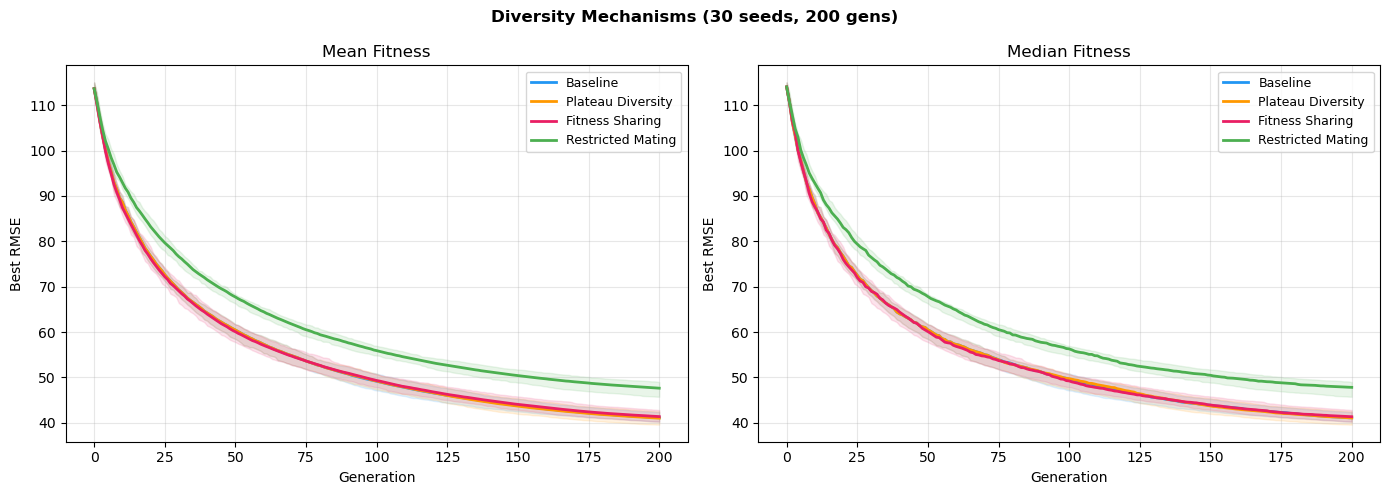

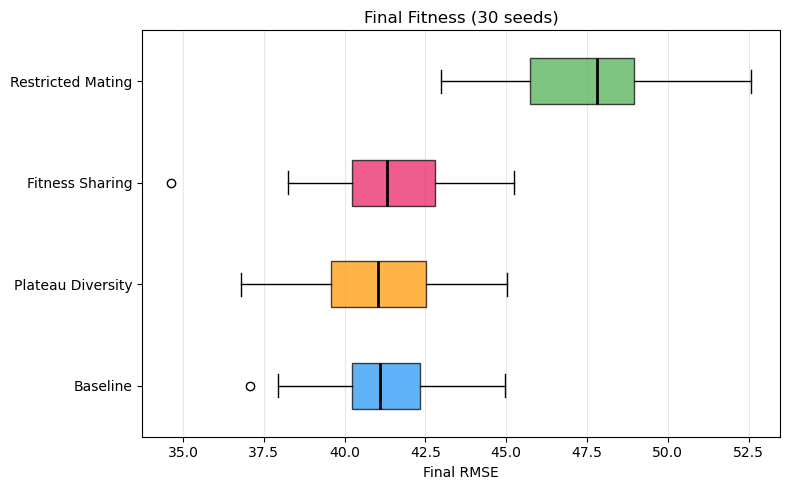

  Baseline vs Plateau Diversity: p=0.3931 ✗
  Baseline vs Fitness Sharing: p=0.7611 ✗
  Baseline vs Restricted Mating: p=0.0000 ✓
  Plateau Diversity vs Fitness Sharing: p=0.6263 ✗
  Plateau Diversity vs Restricted Mating: p=0.0000 ✓
  Fitness Sharing vs Restricted Mating: p=0.0000 ✓


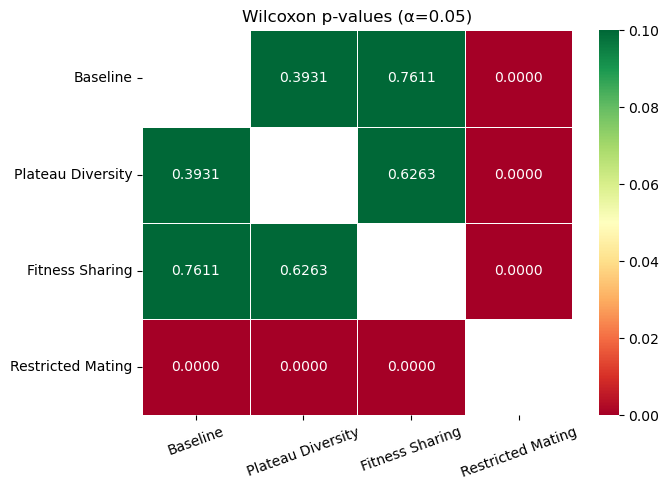

In [ ]:
COLORS_DIV = {
    "Baseline":          "#2196F3",
    "Plateau Diversity": "#FF9800",
    "Fitness Sharing":   "#E91E63",
    "Restricted Mating": "#4CAF50",
}
variants = {
    "Baseline":          (hist_base,    final_base),
    "Plateau Diversity": (hist_plateau, final_plateau),
    "Fitness Sharing":   (hist_fs,      final_fs),
    "Restricted Mating": (hist_rm,      final_rm),
}
min_len = min(min(len(h) for h in hists) for hists, _ in variants.values())
mats    = {k: np.vstack([h[:min_len] for h in hists]) for k, (hists, _) in variants.items()}

# Convergence curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Diversity Mechanisms ({N_DIV_SEEDS} seeds, {DIV_MAX_GENS} gens)", fontsize=12, fontweight="bold")
for ax, (stat_label, fn) in zip(axes, [("Mean", np.mean), ("Median", np.median)]):
    for label, mat in mats.items():
        curve = fn(mat, axis=0)
        ax.plot(np.arange(min_len), curve, label=label, color=COLORS_DIV[label], linewidth=2)
        ax.fill_between(np.arange(min_len), np.quantile(mat, 0.25, axis=0), np.quantile(mat, 0.75, axis=0), color=COLORS_DIV[label], alpha=0.12)
    ax.set_title(f"{stat_label} Fitness"); ax.set_xlabel("Generation"); ax.set_ylabel("Best RMSE")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Boxplots
fig, ax = plt.subplots(figsize=(8, 5))
finals = [final for _, final in variants.values()]
bp = ax.boxplot(finals, vert=False, patch_artist=True, widths=0.45,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], COLORS_DIV.values()):
    patch.set_facecolor(color); patch.set_alpha(0.72)
ax.set_yticks([1, 2, 3, 4]); ax.set_yticklabels(COLORS_DIV.keys(), fontsize=10)
ax.set_xlabel("Final RMSE"); ax.set_title(f"Final Fitness ({N_DIV_SEEDS} seeds)"); ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# Wilcoxon pairwise heatmap
labels_w = list(variants.keys())
n = len(labels_w)
p_mat = pd.DataFrame(np.ones((n, n)), index=labels_w, columns=labels_w)
for l1, l2 in combinations(labels_w, 2):
    _, p = wilcoxon(variants[l1][1], variants[l2][1], alternative="two-sided")
    p_mat.loc[l1, l2] = p_mat.loc[l2, l1] = p
    print(f"  {l1} vs {l2}: p={p:.4f} {'✓' if p < ALPHA_DIV else '✗'}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(p_mat, annot=True, fmt=".4f", cmap="RdYlGn", vmin=0, vmax=0.10,
            linewidths=0.5, mask=np.eye(n, dtype=bool), ax=ax)
ax.set_title(f"Wilcoxon p-values (α={ALPHA_DIV})")
ax.tick_params(axis="x", rotation=20); ax.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.show()

### Results

Baseline, Plateau Diversity, and Fitness Sharing converge at nearly identical rates throughout the 200 generations, with their IQR bands almost completely overlapping. Restricted Mating is consistently slower from the first generation, finishing roughly 6.5 RMSE points above the other three. The Wilcoxon test confirms this: Baseline vs Plateau (p=0.39) and Baseline vs Fitness Sharing (p=0.76) show no statistically significant difference, while Restricted Mating is significantly worse than all three (p=0.0000). Plateau Diversity vs Fitness Sharing is also not significant (p=0.63).

It should be noted that 200 generations (this number is low due to hardware constraints) is a short budget for evaluating diversity mechanisms - Plateau Diversity and Fitness Sharing are designed to help in later stages when the population stagnates, a phenomenon that is more pronounced in longer runs. The results are therefore not conclusive for these two mechanisms, but already give a clear signal: Restricted Mating is actively harmful in short runs, and neither Plateau nor Fitness Sharing offer a statistically detectable advantage over the baseline at this scale. The long run uses Plateau Diversity with a wider window (40 generations) to avoid premature triggering.

## Long Run - RMSE

Having confirmed that the Memetic GA significantly outperforms the pure GA, we now run the full 6000-generation experiment with the best configuration:
tournament selection, mixed mutation, plateau diversity (window=40), and periodic HC refinement every 300 generations. A final HC polishing pass
(2000 iterations, 20 neighbours) is applied after the loop.

In [11]:
MAX_GENS = 6000

# Hill Climbing constants
HC_ITERATIONS = 80
HC_NEIGHBORS = 15
HC_MUT_PROB = 0.03
HC_SIGMA_SCALE = 0.10


def run_solution_experiment(
    solution_class,
    params,
    run_name,
    fitness_label,
    final_refine=True,
    max_generations=MAX_GENS,
):
    """Run one full GA experiment and persist artifacts.

    Args:
        solution_class: Solution class used to instantiate the population.
        params: GA parameter dictionary with operators and GA settings.
        run_name: Relative folder name under `RESULTS_DIR` for artifacts.
        fitness_label: Label used in progress logs.
        final_refine: Whether to run final hill-climbing refinement.
        max_generations: Number of generations for the GA run.

    Returns:
        A tuple `(best_solution, fitness_history, metrics_history)`.
    """
    run_dir = RESULTS_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    selection_algorithm, xo_method, mut_method = build_ga_operators(params)
    settings = {
        **params["ga_settings"],
        "verbose": True,
        "return_metrics": True,
        "run_name": run_name,
        "save_best_per_generation": True,
        "hc_refine_every": 300,
        "hc_iterations": HC_ITERATIONS,
        "hc_neighbors": HC_NEIGHBORS,
        "hc_mut_prob": HC_MUT_PROB,
        "hc_sigma_scale": HC_SIGMA_SCALE,
        "hc_mut_method": gaussian_mutation,
    }

    print(f"Starting {fitness_label} GA run with pop_size={params['pop_size']} for {max_generations} generations...")
    best_solution, fitness_history, metrics_history = genetic_algorithm(
        initial_population=[solution_class() for _ in range(params["pop_size"])],
        max_generations=max_generations,
        selection_algorithm=selection_algorithm,
        xo_method=xo_method,
        mut_method=mut_method,
        settings=settings,
    )

    if final_refine:
        refined = hill_climbing_refine(
            best_solution,
            gaussian_mutation,
            mut_prob=0.02,
            sigma_scale=0.05,
            n_iterations=2000,
            n_neighbors=20,
        )
        if refined.fitness() < best_solution.fitness():
            best_solution = refined

    print(f"Best {fitness_label}: {best_solution.fitness():.4f}")

    with open(run_dir / "best_repr.pkl", "wb") as handle:
        pickle.dump(best_solution.repr, handle)

    best_image_path = best_solution.save_render(run_dir / "best.png")
    print(f"Saved best image: {best_image_path}")

    frame_count = len(list(run_dir.glob("gen_*.png")))
    print(f"Saved frames: {frame_count}")

    return best_solution, fitness_history, metrics_history


def run_and_report_experiment(
    solution_class,
    params,
    run_name,
    fitness_label,
    final_refine=True,
    max_generations=MAX_GENS,
):
    """Run one experiment, generate GIF, and plot summary.

    Args:
        solution_class: Solution class used to instantiate the population.
        params: GA parameter dictionary with operators and GA settings.
        run_name: Relative folder name under `RESULTS_DIR` for artifacts.
        fitness_label: Label used for logging and plotting.
        final_refine: Whether to run final hill-climbing refinement.
        max_generations: Number of generations for the GA run.

    Returns:
        A tuple `(best_solution, fitness_history, metrics_history, gif_path)`.
    """
    random.seed(DEFAULT_SEED)
    np.random.seed(DEFAULT_SEED)

    best_solution, fitness_history, metrics_history = run_solution_experiment(
        solution_class=solution_class,
        params=params,
        run_name=run_name,
        fitness_label=fitness_label,
        final_refine=final_refine,
        max_generations=max_generations,
    )

    gif_path = create_run_gif(run_name)
    plot_run_summary(
        best_solution,
        fitness_history,
        metrics_history,
        fitness_label,
        target_array,
    )

    print(f"Run folder for {fitness_label}: {run_name}")
    print(f"GIF: {gif_path}")

    return best_solution, fitness_history, metrics_history, gif_path

rmse_params = {
    "pop_size": 100,
    "selection_name": "tournament",
    "crossover_name": "uniform",
    "mutation_name": "mixed",
    "tournament_size": 5,
    "swap_weight": 0.11,
    "ga_settings": {
        "xo_prob": 0.87,
        "mut_prob": 0.021,
        "elitism": True,
        "n_elites": 1,
        "verbose": False,
        "diversify_on_plateau": True,
        "plateau_window": 40,
        "plateau_epsilon": 0.05,
        "mut_sigma_start": 1.30,
        "mut_sigma_end": 0.16,
        "hc_refine_every": 0,
    },
    "selected_experiment": "manual_tuned",
    "solution_class": "TriangleSolution",
}

Starting RMSE GA run with pop_size=100 for 6000 generations...
Gen    1 | best = 110.2246 | H_p = 0.897 | H_g = 0.939
Gen   10 | best = 83.5240 | H_p = 0.931 | H_g = 0.605
Gen   20 | best = 71.9228 | H_p = 0.786 | H_g = 0.522
Gen   30 | best = 65.5208 | H_p = 0.731 | H_g = 0.489
Gen   40 | best = 60.8312 | H_p = 0.859 | H_g = 0.471
Gen   50 | best = 57.4324 | H_p = 0.532 | H_g = 0.483
Gen   60 | best = 54.1263 | H_p = 0.590 | H_g = 0.465
Gen   70 | best = 51.8499 | H_p = 0.739 | H_g = 0.466
Gen   80 | best = 49.8512 | H_p = 0.588 | H_g = 0.466
Gen   90 | best = 47.8900 | H_p = 0.801 | H_g = 0.486
Gen  100 | best = 45.9642 | H_p = 0.535 | H_g = 0.468
Gen  110 | best = 44.5679 | H_p = 0.280 | H_g = 0.466
Gen  120 | best = 42.7772 | H_p = 0.639 | H_g = 0.440
Gen  130 | best = 41.7032 | H_p = 0.357 | H_g = 0.429
Gen  140 | best = 40.3657 | H_p = 0.656 | H_g = 0.417
Gen  150 | best = 39.4307 | H_p = 0.572 | H_g = 0.362
Gen  160 | best = 38.8678 | H_p = 0.257 | H_g = 0.358
Gen  170 | best = 

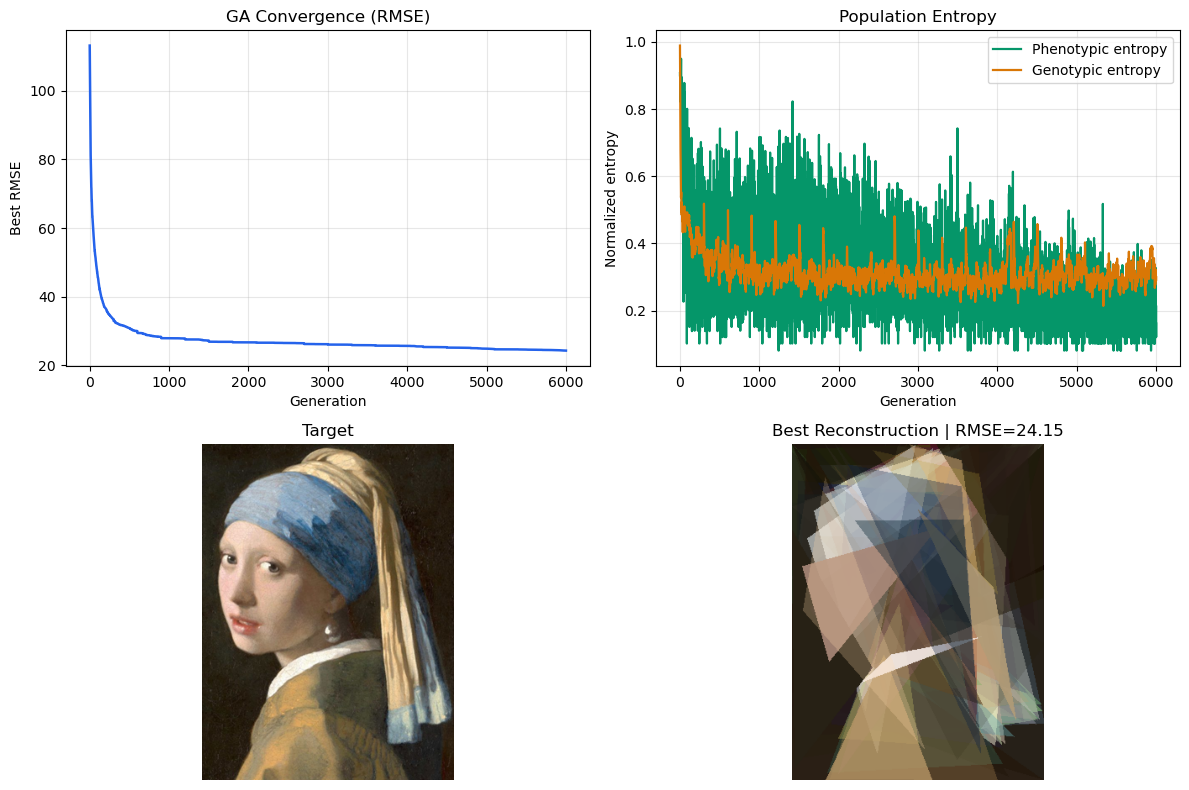

Run folder for RMSE: rmse
GIF: /Users/pedro/Documents/DSAA/2semester/CIFO/Project/cifo/results/rmse/timelapse.gif
Saved evolution CSV: /Users/pedro/Documents/DSAA/2semester/CIFO/Project/cifo/results/rmse/tuning.csv
Saved best solution: /Users/pedro/Documents/DSAA/2semester/CIFO/Project/cifo/results/rmse/best_repr.pkl


In [12]:
# RMSE long run
rmse_run_name = "rmse"
rmse_best_solution, rmse_fitness_history, rmse_metrics_history, rmse_gif_path = run_and_report_experiment(
    solution_class=TriangleSolution,
    params=rmse_params,
    run_name=rmse_run_name,
    fitness_label="RMSE",
)

run_dir = RESULTS_DIR / rmse_run_name
run_dir.mkdir(parents=True, exist_ok=True)

# Save evolution metrics
csv_path = run_dir / "tuning.csv"
with open(csv_path, "w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow([
        "generation",
        "best_fitness",
        "avg_fitness",
        "phenotypic_entropy",
        "genotypic_entropy",
        "fitness_variance",
        "genotypic_variance",
    ])
    for gen, best in enumerate(rmse_fitness_history):
        writer.writerow([
            gen,
            best,
            rmse_metrics_history["avg_fitness"][gen],
            rmse_metrics_history["phenotypic_entropy"][gen],
            rmse_metrics_history["genotypic_entropy"][gen],
            rmse_metrics_history["fitness_variance"][gen],
            rmse_metrics_history["genotypic_variance"][gen],
        ])
print(f"Saved evolution CSV: {csv_path}")

# Save best solution
pkl_path = run_dir / "best_repr.pkl" # overwrite with new best solution, the random search best solution is worse
with open(pkl_path, "wb") as handle:
    pickle.dump(rmse_best_solution, handle)
print(f"Saved best solution: {pkl_path}")

Note: The folder name was changed to keep both this one and the Random Search one. rmse -> tuned_rmse

## Long Run - Fitness Sharing (Exploratory)

The diversity comparison showed no statistically significant difference between Fitness Sharing and the Baseline in 200 generations. To verify whether FS
offers a benefit over a full run, we run a single 6000-generation experiment replacing plateau diversity with Fitness Sharing, keeping all other parameters identical. If the final RMSE is lower than the baseline (24.1458), FS becomes the preferred final configuration; otherwise the plateau diversity result is kept.

In [ ]:
def run_fs_experiment(seed=DEFAULT_SEED, sigma=0.25, alpha=1.0, max_generations=MAX_GENS):
    """Long run with Fitness Sharing instead of plateau diversity.

    Args:
        seed: Random seed for reproducibility.
        sigma: Niche radius for sharing function.
        alpha: Sharing function shape exponent.
        max_generations: Number of generations to run.

    Returns:
        A tuple (best_solution, fitness_history).
    """
    random.seed(seed); np.random.seed(seed)
    run_dir = RESULTS_DIR / "rmsefs"
    run_dir.mkdir(parents=True, exist_ok=True)

    sel, xo, mut = build_ga_operators(rmse_params)
    gs  = {**rmse_params["ga_settings"], "diversify_on_plateau": False}
    pop = [TriangleSolution() for _ in range(rmse_params["pop_size"])]
    _ensure_population_fitness(pop)
    best_ever = deepcopy(min(pop, key=lambda ind: ind.fitness()))
    history   = [best_ever.fitness()]

    for gen in range(1, max_generations + 1):
        sig_scale = gs["mut_sigma_start"] + (gs["mut_sigma_end"] - gs["mut_sigma_start"]) * (gen / max_generations)
        dist   = _pairwise_norm_distances(pop)
        sh_mat = np.where(dist < sigma, 1.0 - (dist / sigma)**alpha, 0.0)
        np.fill_diagonal(sh_mat, 1.0)
        raw_f  = np.array([ind.fitness() for ind in pop])
        order  = np.argsort(raw_f * sh_mat.sum(axis=1))
        pop_s  = [pop[i] for i in order]
        elites  = [deepcopy(pop[i]) for i in np.argsort(raw_f)[:gs["n_elites"]]]
        new_pop = elites[:]
        while len(new_pop) < len(pop):
            p1, p2 = sel(pop_s), sel(pop_s)
            o1, o2 = xo(p1, p2) if random.random() < gs["xo_prob"] else (deepcopy(p1), deepcopy(p2))
            new_pop.append(mut(o1, gs["mut_prob"], sigma_scale=sig_scale))
            if len(new_pop) < len(pop):
                new_pop.append(mut(o2, gs["mut_prob"], sigma_scale=sig_scale))
        pop       = new_pop
        _ensure_population_fitness(pop)
        gen_best  = min(pop, key=lambda ind: ind.fitness())
        if gen_best.fitness() < best_ever.fitness():
            best_ever = deepcopy(gen_best)
        history.append(best_ever.fitness())

        # Save frame for timelapse
        Image.fromarray(best_ever.render().astype(np.uint8)).save(run_dir / f"gen_{gen:04d}.png")

        if gen % 10 == 0 or gen == 1:
            print(f"Gen {gen:>4d} | best = {best_ever.fitness():.4f}")

    # Final HC polishing
    refined = hill_climbing_refine(
        best_ever, gaussian_mutation, mut_prob=0.02, sigma_scale=0.05,
        n_iterations=2000, n_neighbors=20,
    )
    if refined.fitness() < best_ever.fitness():
        best_ever = refined

    print(f"Best RMSE (FS): {best_ever.fitness():.4f}")
    return best_ever, history

In [7]:
fs_best, fs_history = run_fs_experiment(seed=DEFAULT_SEED, max_generations=MAX_GENS)

run_dir = RESULTS_DIR / "rmsefs"

# Timelapse GIF
fs_gif_path = create_run_gif("rmsefs")
print(f"GIF: {fs_gif_path}")

# Save best image
fs_best.save_render(run_dir / "best.png")

# Save tuning CSV
csv_path = run_dir / "tuning.csv"
with open(csv_path, "w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow([
        "generation",
        "best_fitness",
    ])
    for gen, best in enumerate(fs_history):
        writer.writerow([gen, best])
print(f"Saved CSV: {csv_path}")

# Save best solution
pkl_path = run_dir / "best_repr.pkl"
with open(pkl_path, "wb") as handle:
    pickle.dump(fs_best, handle)
print(f"Saved pkl: {pkl_path}")

print(f"\nFS best RMSE : {fs_best.fitness():.4f}")
print(f"Baseline RMSE: 24.1458")
print("Improvement!" if fs_best.fitness() < 24.1458 else "No improvement over baseline")

Gen    1 | best = 110.1892
Gen   10 | best = 85.2146
Gen   20 | best = 74.0351
Gen   30 | best = 66.8802
Gen   40 | best = 62.7715
Gen   50 | best = 59.2367
Gen   60 | best = 55.0153
Gen   70 | best = 51.9285
Gen   80 | best = 49.1430
Gen   90 | best = 46.9948
Gen  100 | best = 45.0479
Gen  110 | best = 43.3716
Gen  120 | best = 42.1405
Gen  130 | best = 40.8180
Gen  140 | best = 40.2012
Gen  150 | best = 39.2665
Gen  160 | best = 38.5097
Gen  170 | best = 37.7164
Gen  180 | best = 37.0657
Gen  190 | best = 36.5222
Gen  200 | best = 36.0667
Gen  210 | best = 35.5671
Gen  220 | best = 35.1091
Gen  230 | best = 34.6432
Gen  240 | best = 34.2287
Gen  250 | best = 33.8401
Gen  260 | best = 33.5166
Gen  270 | best = 33.3730
Gen  280 | best = 33.2234
Gen  290 | best = 33.0210
Gen  300 | best = 32.8142
Gen  310 | best = 32.6600
Gen  320 | best = 32.5558
Gen  330 | best = 32.4999
Gen  340 | best = 32.4130
Gen  350 | best = 32.2686
Gen  360 | best = 32.2310
Gen  370 | best = 32.1625
Gen  380 | 

### Results

The Fitness Sharing long run achieved a final RMSE of 25.1153, compared to 24.1458 from the plateau diversity configuration. The plateau diversity result is therefore kept as the final solution. No statistical test was run for this comparison since it is a single exploratory run, but the difference is large enough to be conclusive - Fitness Sharing does not offer a meaningful advantage over plateau diversity in this problem and the added computational cost of computing pairwise distances at every generation is not justified.